In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [2]:
data = {
    "Size": [500, 800, 1000, 1500, 2000, 3000, 5000],
    "Price": [100000, 150000, 200000, 300000, 500000, 900000, 2000000]
}

In [3]:
df = pd.DataFrame(data)

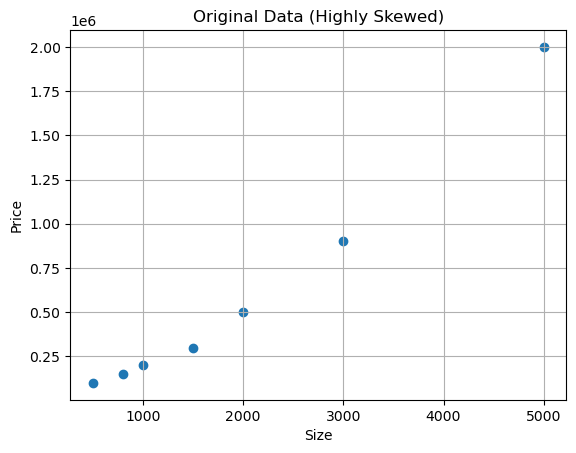

In [5]:
plt.figure()
plt.scatter(df["Size"], df["Price"])
plt.title('Original Data (Highly Skewed)')
plt.xlabel('Size')
plt.ylabel('Price')
plt.grid()
plt.show()

In [6]:
df["log_price"] = np.log(df["Price"])

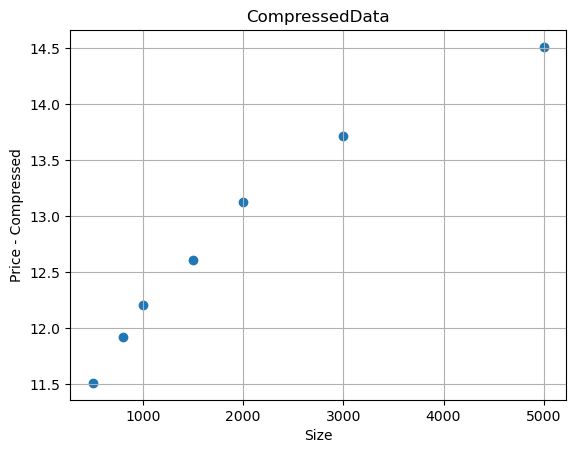

In [29]:
plt.figure()
plt.scatter(df["Size"], df["log_price"])
plt.title('CompressedData')
plt.xlabel('Size')
plt.ylabel('Price - Compressed')
plt.grid()
plt.show()

In [30]:
model_original = LinearRegression()
model_log = LinearRegression()

In [31]:
model_original.fit(df[['Size']], df['Price'])

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [32]:
model_log.fit(df[['Size']], df['log_price'])

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


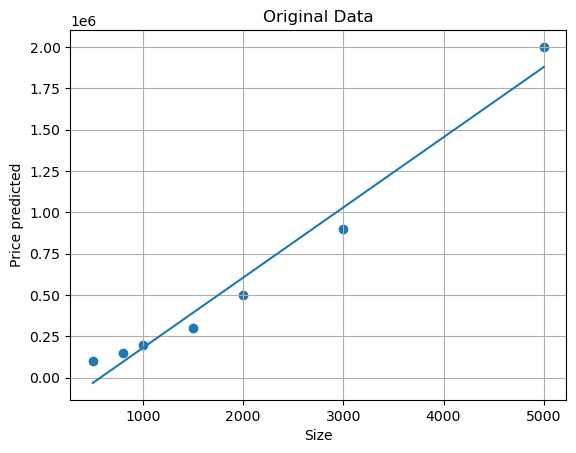

In [33]:
plt.figure()
plt.scatter(df['Size'], df['Price'])
plt.plot(df[["Size"]], model_original.predict(df[['Size']]), label='Orignal linear regression data line')
plt.title('Original Data')
plt.xlabel('Size')
plt.ylabel('Price predicted')
plt.grid()
plt.show()

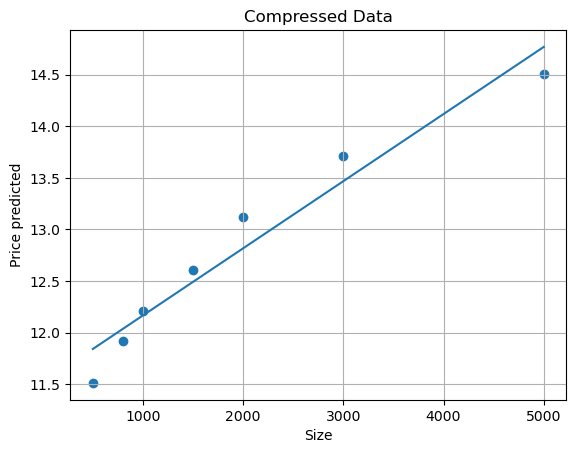

In [19]:
plt.figure()
plt.scatter(df['Size'], df['log_price'])
plt.plot(df[["Size"]], (model_log.predict(df[['Size']])), label='Compressed linear regression data line')
plt.title('Compressed Data')
plt.xlabel('Size')
plt.ylabel('Price predicted')
plt.grid()
plt.show()

In [34]:
mse_orig = mean_squared_error(df[['Size']], model_original.predict(df[['Size']]))
mse_log = mean_squared_error(df[['Size']], np.exp(model_log.predict(df[['Size']])))

In [35]:
mse_orig

731663496837.3008

In [36]:
mse_log

1068441020639.2133

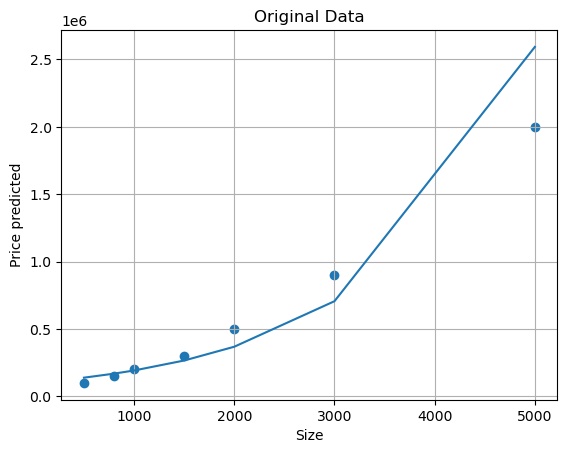

In [37]:
plt.figure()
plt.scatter(df['Size'], df['Price'])
plt.plot(df[["Size"]], np.exp(model_log.predict(df[['Size']])), label='Orignal linear regression data line')
plt.title('Original Data')
plt.xlabel('Size')
plt.ylabel('Price predicted')
plt.grid()
plt.show()